# Data Acquisition 

Importing all the basic libraries

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importing the Dataset of Loan Approval

In [117]:
dataset = pd.read_csv('D:\\CVprojects\\train.csv')

Understanding the data

In [118]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


In [119]:
dataset.shape

(3192, 14)

In [120]:
dataset.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Age
count,3192.000000,3157.000000,3192.000000,3151.000000,3192.000000,3192.000000,3192.000000
mean,1.011905,59962.641490,15091.342368,151459.710168,212.368421,0.516917,35.201381
std,0.983975,19932.955795,9541.479521,50313.610809,101.428986,0.499792,7.722665
min,0.000000,15000.000000,0.000000,20000.000000,60.000000,0.000000,21.000000
25%,0.000000,46485.838417,7915.099793,116986.769053,120.000000,0.000000,29.853657
50%,1.000000,60290.179985,14608.469288,151967.787750,240.000000,1.000000,35.054461
75%,2.000000,73118.015531,21758.376019,186201.802079,300.000000,1.000000,40.537728
max,3.000000,138524.754129,47877.611874,373954.212551,360.000000,1.000000,61.159254


# Exploratory Data Analysis

<Axes: xlabel='Gender', ylabel='count'>

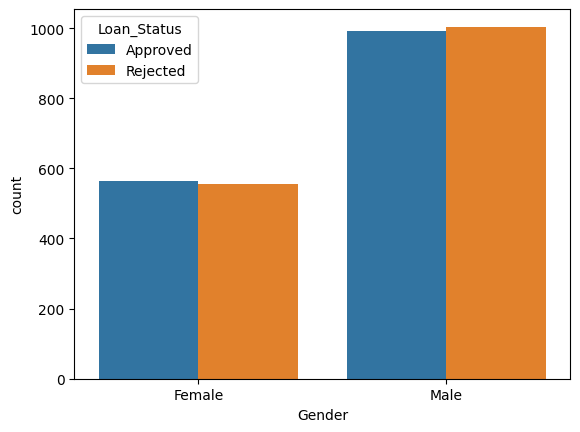

In [121]:
sns.countplot(x = 'Gender', hue = 'Loan_Status', data = dataset)

<Axes: xlabel='Married', ylabel='count'>

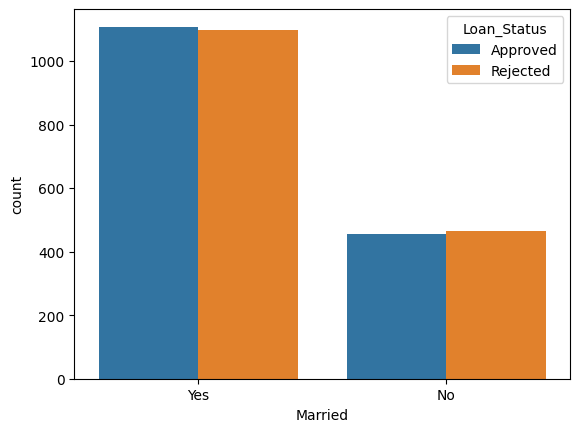

In [122]:
sns.countplot(x = 'Married', hue = 'Loan_Status', data = dataset)

From the above violin plot, we can conclude that 'Applicant_Income' is not a strong influencer feature for the 'Loan_Status'.

<Axes: xlabel='Education', ylabel='count'>

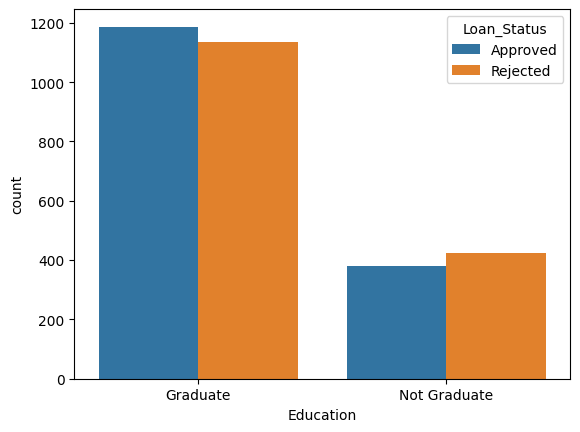

In [123]:
sns.countplot(x = 'Education', hue = 'Loan_Status', data = dataset)

<Axes: xlabel='Loan_Term', ylabel='count'>

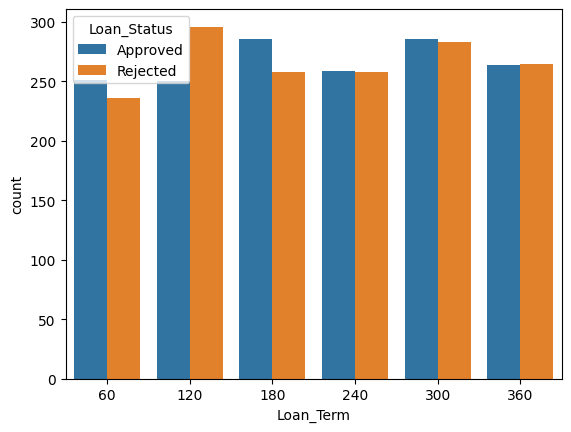

In [124]:
sns.countplot(x = 'Loan_Term', hue = 'Loan_Status', data = dataset)

<Axes: xlabel='Employment_Status', ylabel='count'>

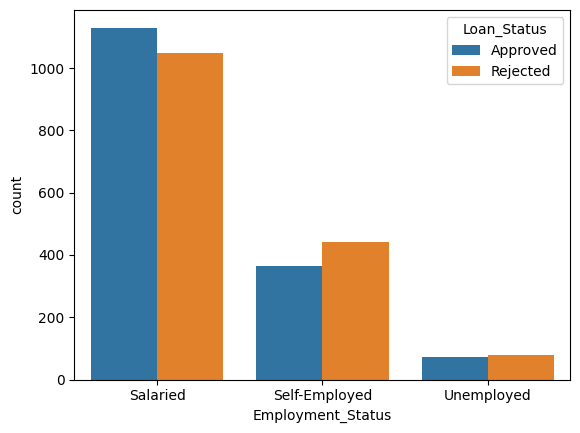

In [125]:
sns.countplot(x = 'Employment_Status', hue = 'Loan_Status', data = dataset)

<Axes: xlabel='Credit_History', ylabel='count'>

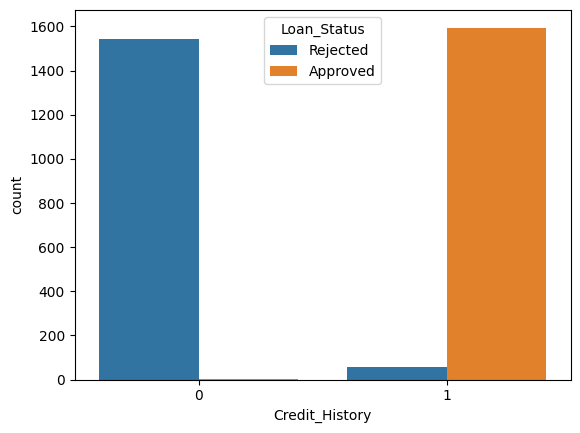

In [126]:
sns.countplot(x = 'Credit_History', hue = 'Loan_Status', data = dataset)

From all of the above plots, we can observe that 'Credit_History' has great influence on 'Loan_Status' while 'Loan_Status' is not that much influenced by the other features.

<Axes: xlabel='Credit_History', ylabel='Age'>

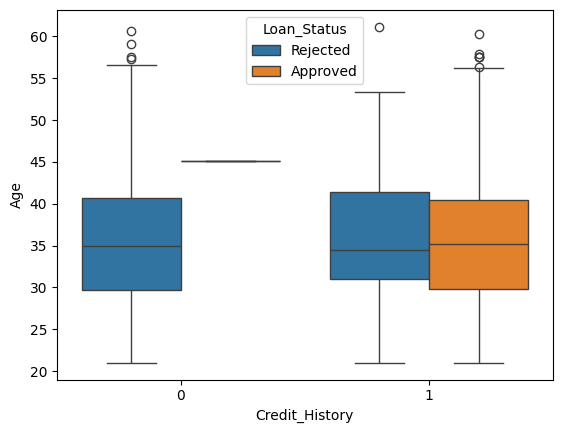

In [127]:
sns.boxplot(x='Credit_History', y='Age', hue='Loan_Status', data=dataset)

<Axes: xlabel='Credit_History', ylabel='Applicant_Income'>

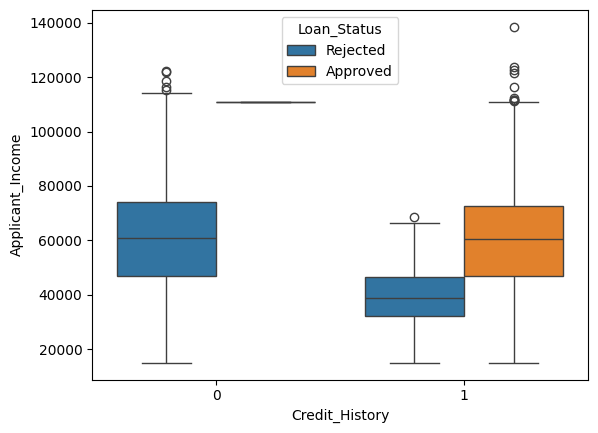

In [128]:
sns.boxplot(x='Credit_History', y='Applicant_Income', hue='Loan_Status', data=dataset)

<Axes: xlabel='Loan_Status', ylabel='Age'>

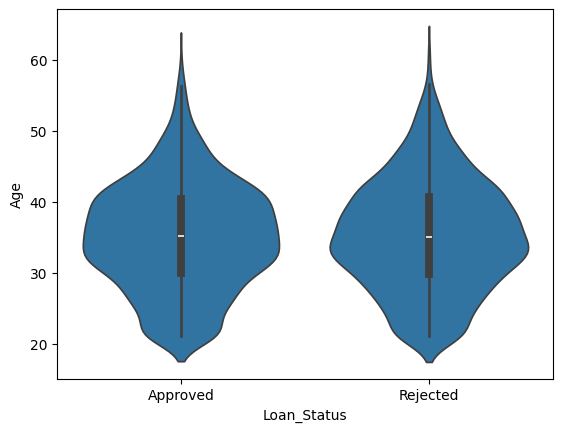

In [129]:
sns.violinplot(x = 'Loan_Status', y = 'Age', data = dataset)

<Axes: xlabel='Loan_Status', ylabel='Applicant_Income'>

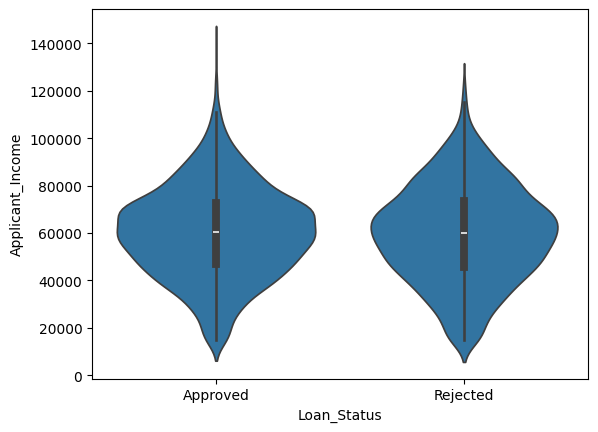

In [130]:
sns.violinplot(x='Loan_Status', y='Applicant_Income', data=dataset)

By combining the features with 'Credit_History' only, having the influence on the 'Loan_Status'. Hence, 'Credit_History' dominates.

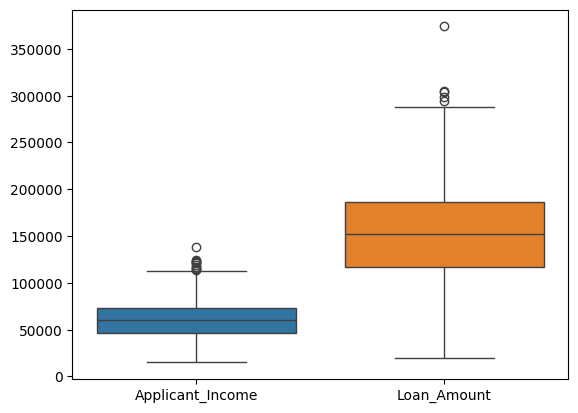

In [131]:
sns.boxplot(data = dataset[['Applicant_Income','Loan_Amount']])
plt.show()

From the BoxPlot, we can observe that there are some outliers in the features 'Applicant_Income' and 'Loan_Amount'

# Data Pre-Processing

In [132]:
dataset.isnull().sum()

Loan_ID                0
Gender                77
Married               66
Dependents             0
Education             66
Employment_Status     56
Applicant_Income      35
Coapplicant_Income     0
Loan_Amount           41
Loan_Term              0
Credit_History         0
Property_Area          0
Age                    0
Loan_Status            0
dtype: int64

After getting into the dataset, we can observe that there are missing values in different rows like one or two missing values in one row but not whole row containing the missing values. So, to avoid unnecessary shrinking of the dataset and also to preserve the importance of each data, replacing missing values with mode, mean or median of those column values.

We can replace the categorical values with mode but for the numerical values, we have mean and median. So plotting the distribution curve for those features.

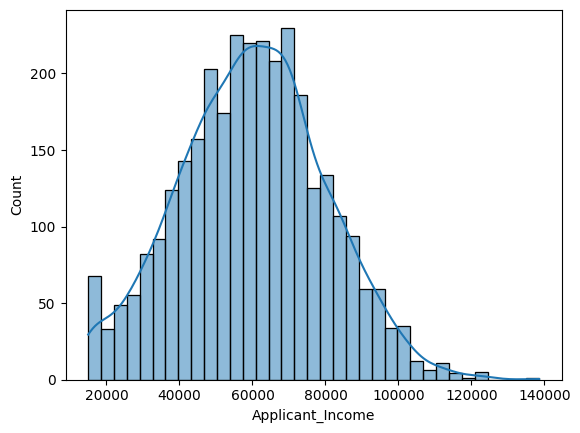

In [133]:
sns.histplot(dataset['Applicant_Income'], kde = True)
plt.show()

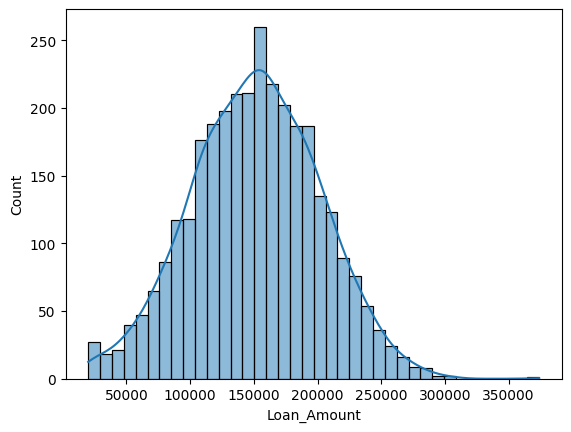

In [134]:
sns.histplot(dataset['Loan_Amount'], kde = True)
plt.show()

In [135]:
print("Skewness:", dataset['Applicant_Income'].skew())
print("Skewness:", dataset['Loan_Amount'].skew())


Skewness: 0.05272819235116843
Skewness: -0.013878286546470293


From the plots, we can observe that the data are almost normally distributed which we can validate from the skewness also. Since, skewness is very close to 0, we can use any of the mean or median, as for such skewness mean is nearly equal to median. Hence, chosing mean for further process.

In [136]:
dataset.fillna({'Gender' : dataset['Gender'].mode()[0]}, inplace=True)
dataset.fillna({'Married' : dataset['Married'].mode()[0]}, inplace=True)
dataset.fillna({'Education' : dataset['Education'].mode()[0]}, inplace=True)
dataset.fillna({'Employment_Status' : dataset['Employment_Status'].mode()[0]}, inplace=True)

dataset.fillna({'Applicant_Income': dataset['Applicant_Income'].mean()}, inplace = True)
dataset.fillna({'Loan_Amount': dataset['Loan_Amount'].mean()}, inplace = True)

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,LN02182,Female,Yes,0,Graduate,Self-Employed,56392.166365,14981.712412,140736.704253,360,1,Urban,32.400614,Approved
3188,LN05878,Male,Yes,2,Graduate,Salaried,43651.837312,17991.997661,67482.274792,180,1,Rural,41.470691,Approved
3189,LN03290,Male,Yes,0,Not Graduate,Salaried,88370.626903,8276.064157,113500.166421,300,1,Rural,45.278707,Approved
3190,LN00770,Male,No,1,Not Graduate,Salaried,74155.038709,14679.525058,214897.009677,360,1,Urban,26.601067,Approved


Checking whether the missing values have been replaced or not

In [137]:
dataset.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents            0
Education             0
Employment_Status     0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Term             0
Credit_History        0
Property_Area         0
Age                   0
Loan_Status           0
dtype: int64

In [138]:
print(dataset['Gender'].value_counts())
print('Uniques classes in Gender : ', dataset['Gender'].nunique())

Gender
Male      2072
Female    1120
Name: count, dtype: int64
Uniques classes in Gender :  2


In [139]:
print(dataset['Loan_Status'].value_counts())
print('Unique classes in Loan_Status : ', dataset['Loan_Status'].nunique())

Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64
Unique classes in Loan_Status :  2


Hence, we have the balanced dataset

Here there are 3192 samples with 14 features. Looking at the data, I can see that all the features in the dataset are not important like 'Loan_ID', 'Dependents', 'Loan_Term'. 

In [ ]:
cols_to_encode = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

dataset = pd.get_dummies(dataset, columns=cols_to_encode, drop_first=True)

In [161]:
dataset['Total_Income'] = dataset['Applicant_Income'] + dataset['Coapplicant_Income']

<Axes: xlabel='Loan_Status', ylabel='Total_Income'>

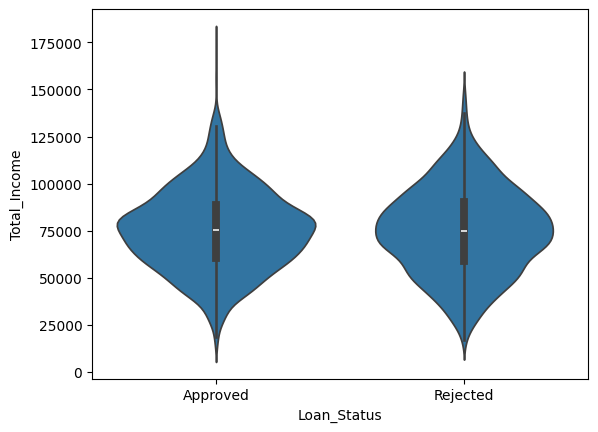

In [164]:
sns.violinplot(x = 'Loan_Status', y = 'Total_Income', data = dataset)

Instead of having two features, combining both features 'Applicant_Income' and 'Coapplicant_Income' to the 'Total_Income' as it represents whether the person can repay the loean or not.

In [162]:
dataset

,Loan_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Age,Loan_Status,Gender_Male,Married_Yes,Education_Not_Graduate,Employment_Status_Self-Employed,Employment_Status_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Total_Income
0,LN03437,3,34473.911669,13914.721574,240732.458366,180,1,40.084028,Approved,False,True,False,False,False,True,False,48388.633244
1,LN04823,1,59718.020682,18720.814787,122547.278442,180,1,47.243644,Approved,False,True,False,True,False,True,False,78438.835469
2,LN04186,1,106981.515734,2229.154377,140550.937774,60,1,24.292070,Approved,False,True,True,False,False,False,False,109210.670111
3,LN00380,2,43205.563156,35578.111771,146135.738127,120,1,38.742244,Approved,True,True,False,False,False,True,False,78783.674927
4,LN04698,0,62526.283990,20212.157912,203408.051744,180,1,41.164721,Approved,False,True,False,False,False,True,False,82738.441902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3187,LN02182,0,56392.166365,14981.712412,140736.704253,360,1,32.400614,Approved,False,True,False,True,False,False,True,71373.878776
3188,LN05878,2,43651.837312,17991.997661,67482.274792,180,1,41.470691,Approved,True,True,False,False,False,False,False,61643.834973
3189,LN03290,0,88370.626903,8276.064157,113500.166421,300,1,45.278707,Approved,True,True,True,False,False,False,False,96646.691060
3190,LN00770,1,74155.038709,14679.525058,214897.009677,360,1,26.601067,Approved,True,False,True,False,False,False,True,88834.563767


In [167]:
X = dataset.drop(['Loan_ID','Dependents','Applicant_Income','Coapplicant_Income','Loan_Term','Loan_Status'], axis = 1)
X

,Loan_Amount,Credit_History,Age,Gender_Male,Married_Yes,Education_Not_Graduate,Employment_Status_Self-Employed,Employment_Status_Unemployed,Property_Area_Semiurban,Property_Area_Urban,Total_Income
0,240732.458366,1,40.084028,False,True,False,False,False,True,False,48388.633244
1,122547.278442,1,47.243644,False,True,False,True,False,True,False,78438.835469
2,140550.937774,1,24.292070,False,True,True,False,False,False,False,109210.670111
3,146135.738127,1,38.742244,True,True,False,False,False,True,False,78783.674927
4,203408.051744,1,41.164721,False,True,False,False,False,True,False,82738.441902
...,...,...,...,...,...,...,...,...,...,...,...
3187,140736.704253,1,32.400614,False,True,False,True,False,False,True,71373.878776
3188,67482.274792,1,41.470691,True,True,False,False,False,False,False,61643.834973
3189,113500.166421,1,45.278707,True,True,True,False,False,False,False,96646.691060
3190,214897.009677,1,26.601067,True,False,True,False,False,False,True,88834.563767


In [141]:
y = dataset['Loan_Status']
y.map({'Approved' : 1, 'Rejected' : 0}).astype(int)

0       1
1       1
2       1
3       1
4       1
       ..
3187    1
3188    1
3189    1
3190    1
3191    0
Name: Loan_Status, Length: 3192, dtype: int64